In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random
import math

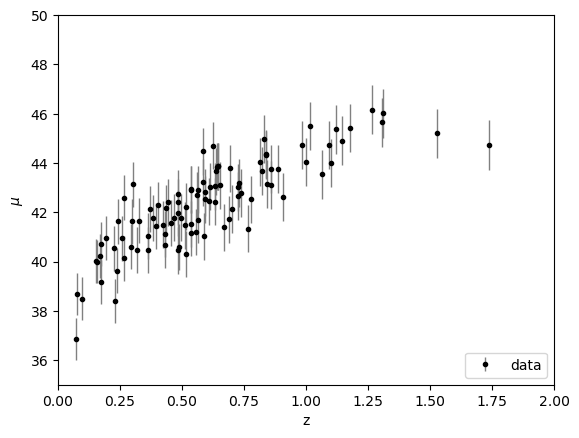

In [29]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

# Polynomial Regression

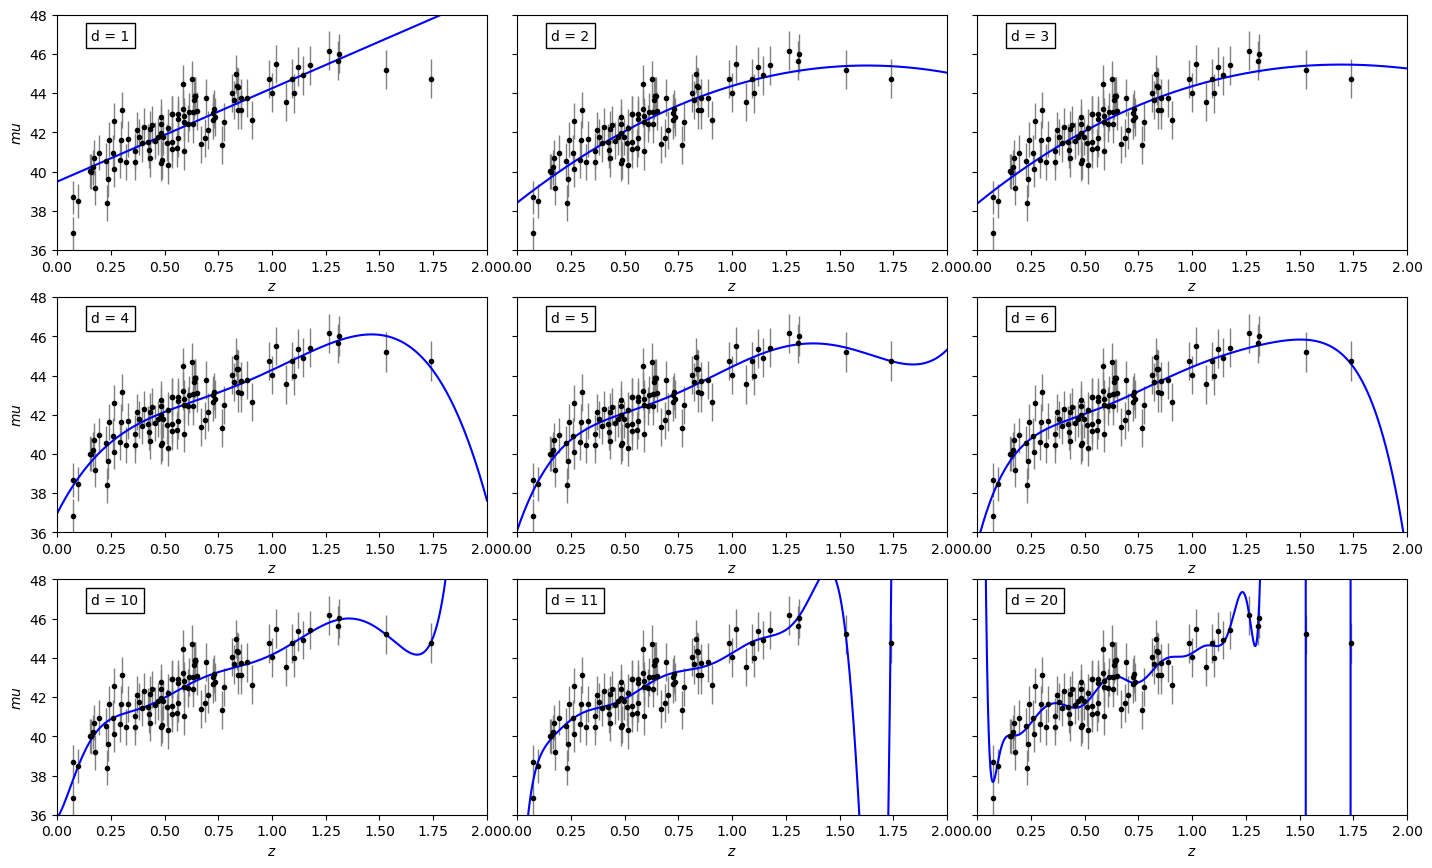

In [171]:
from astroML.linear_model import PolynomialRegression

fig = plt.figure(figsize=(15, 10))
fig.subplots_adjust(wspace=0.07, bottom=0.15, top=0.95, left=0.07, right=0.97)

zgrid = np.linspace(0.0, 2.0, 1000)

for i, d in enumerate([1, 2, 3, 4, 5, 6, 10, 11, 20]):
    model = PolynomialRegression(d) # fit i degree polynomial
    model.fit(z_sample[:,np.newaxis],mu_sample, dmu)
    mu_pred = model.predict(zgrid[:,np.newaxis])
    n_constraints = d + 1

    ax = fig.add_subplot(331 + i)
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    ax.plot(zgrid, mu_pred, '-b')
    if i in (1, 2, 4, 5, 7, 8, 10, 11):
        ax.yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_ylabel('$mu$')
    ax.set_xlabel('$z$')
    ax.set_ylim(36,48)
    ax.set_xlim(0,2)
    ax.text(0.08, 0.94, "d = %i" %d, transform=ax.transAxes, ha='left', va='top', bbox=dict(ec='k', fc='w'))

For d >= 10 is clearly visible how the Polynomial Regression is overfitting the data.

Seems like plynomial degree of 2 or 3 can be the best fit. Let's see:

## Cross Validation

In [172]:
from sklearn.model_selection import GridSearchCV

K = 5 # Do 5-fold cross validation
d = [1, 2, 3, 4, 5, 6, 10, 11, 20]
PolyReg = PolynomialRegression(degree=1)
grid = GridSearchCV(PolyReg, {'degree': d}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
grid.fit(z_sample[:, np.newaxis], mu_sample)
opt_degree = grid.best_params_['degree']
print('Optimal plynomial degree through cross validation: %i' % opt_degree)

Optimal plynomial degree through cross validation: 2


# Basis Function Regression

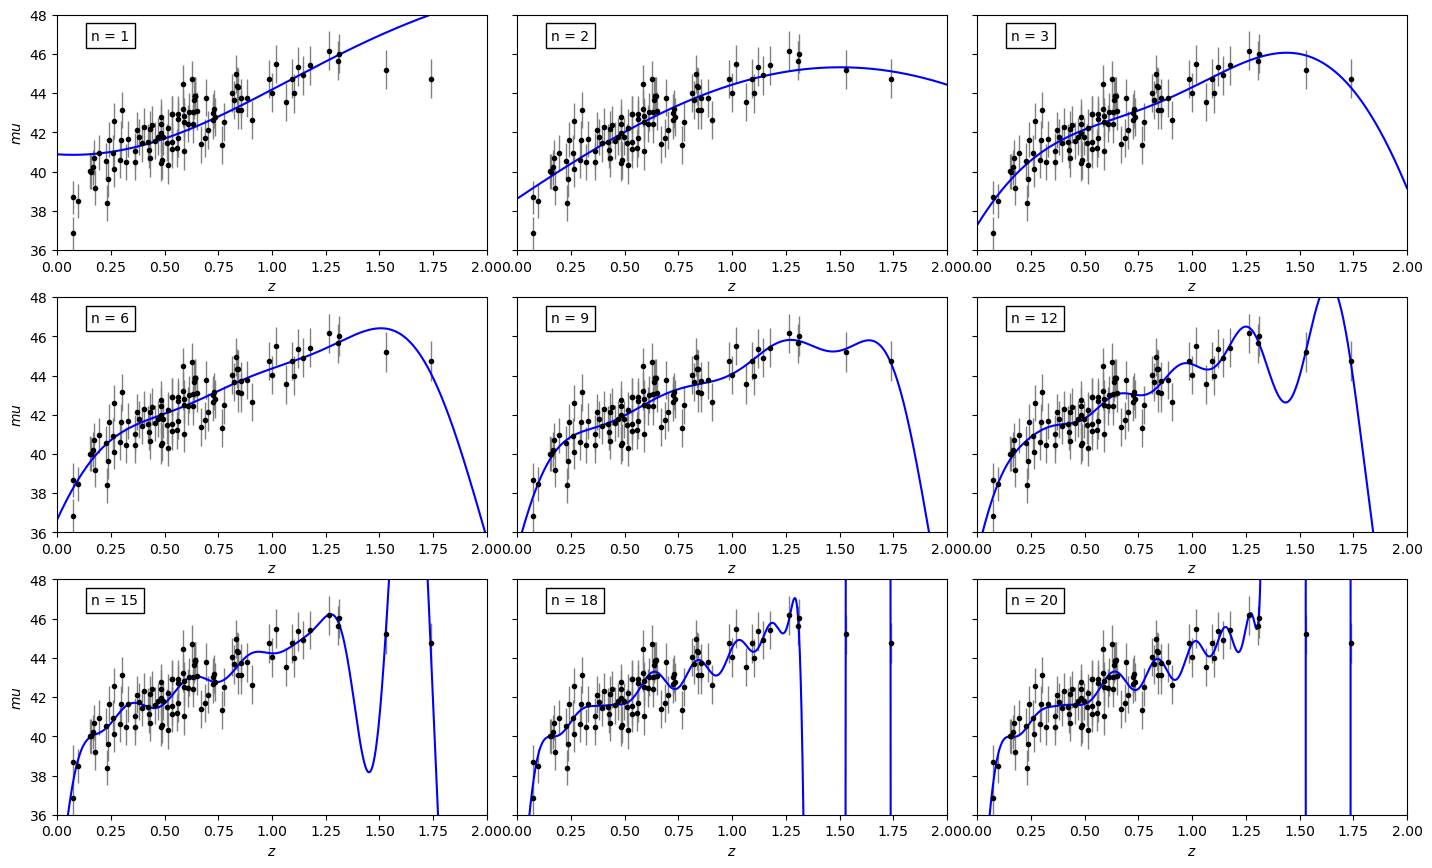

In [173]:
from astroML.linear_model import BasisFunctionRegression

fig = plt.figure(figsize=(15, 10))
fig.subplots_adjust(wspace=0.07, bottom=0.15, top=0.95, left=0.07, right=0.97)

for i, n in enumerate([1, 2, 3, 6, 9, 12, 15, 18, 20]):
    # mean positions of the j Gaussians in the model
    b_mu = np.linspace(np.min(z_sample),np.max(z_sample),n)[:, None]
    if n == 1: 
        b_sigma = 1
    else:
        b_sigma = 1.0 * (b_mu[1] - b_mu[0])
    model = BasisFunctionRegression('gaussian', mu=b_mu, sigma=b_sigma)
    model.fit(z_sample[:, np.newaxis], mu_sample, dmu)
    y_pred = model.predict(zgrid[:, np.newaxis])

    ax = fig.add_subplot(331 + i)
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    ax.plot(zgrid, y_pred, '-b')
    if i in (1, 2, 4, 5, 7, 8, 10, 11):
        ax.yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_ylabel('$mu$')
    ax.set_xlabel('$z$')
    ax.set_ylim(36,48)
    ax.set_xlim(0,2)
    ax.text(0.08, 0.94, "n = %i" %n, transform=ax.transAxes, ha='left', va='top', bbox=dict(ec='k', fc='w'))

# Kernel regression (Nadaraya-Watson)

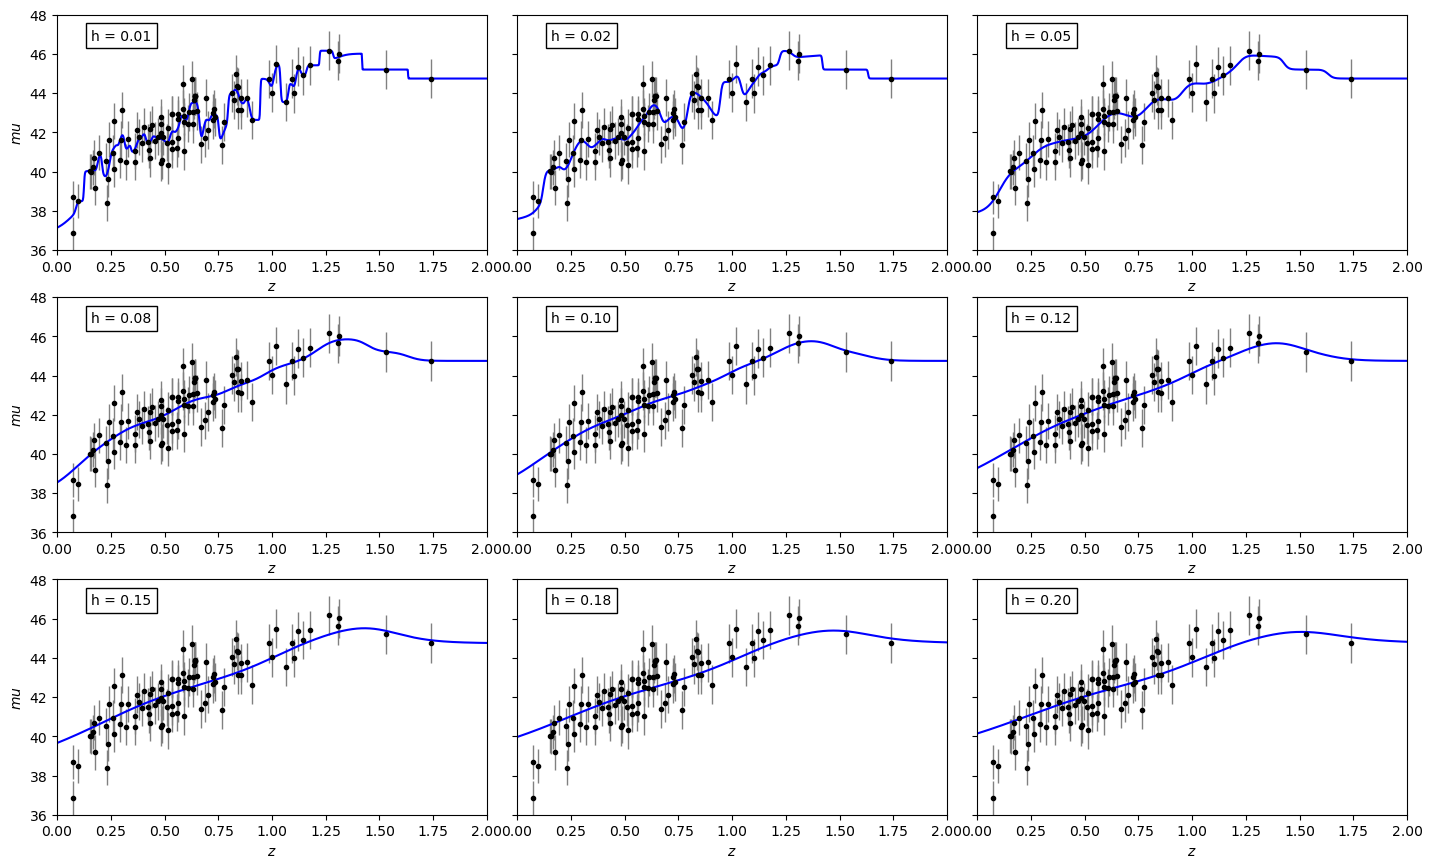

In [174]:
from astroML.linear_model import NadarayaWatson

fig = plt.figure(figsize=(15, 10))
fig.subplots_adjust(wspace=0.07, bottom=0.15, top=0.95, left=0.07, right=0.97)

for i, h in enumerate([0.01, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2]):
    model = NadarayaWatson(kernel='gaussian', h=h)
    model.fit(z_sample[:,np.newaxis],mu_sample, dmu)
    ykr_pred = model.predict(zgrid[:, np.newaxis])

    ax = fig.add_subplot(331 + i)
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    ax.plot(zgrid, ykr_pred, '-b')
    if i in (1, 2, 4, 5, 7, 8, 10, 11):
        ax.yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_ylabel('$mu$')
    ax.set_xlabel('$z$')
    ax.set_ylim(36,48)
    ax.set_xlim(0,2)
    ax.text(0.08, 0.94, "h = %.2f" %h, transform=ax.transAxes, ha='left', va='top', bbox=dict(ec='k', fc='w'))

# Cross Validation and train rms (root mean square) errors

In [175]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate

X = z_sample[:,np.newaxis]
y = mu_sample
dy = dmu

X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

## Polynomial Regression

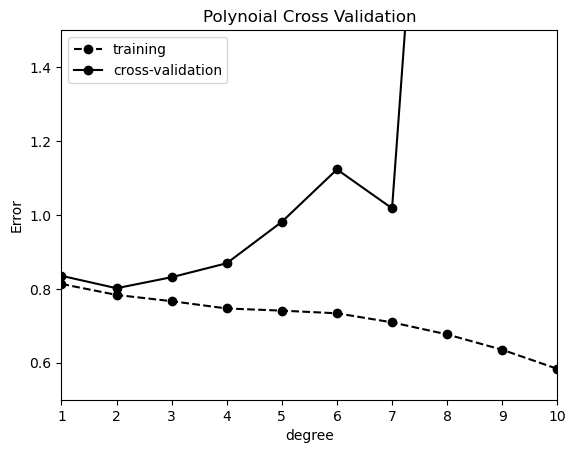

Best degree: 2 0.8016950119634505


In [176]:
K = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = np.arange(1, 11)
train_errors = []
test_errors = []


def error (y_true, y_pred):
    return np.sqrt( np.sum(( y_true - y_pred )**2) / len(y_true) )

scorer = make_scorer(error)

for degree in degrees:
    model = PolynomialRegression(degree)
    
    scores = cross_validate(model, X_validation, y_validation,
                            scoring=scorer, cv=K,
                            return_train_score=True)

    test_score = np.mean(scores['test_score']) 
    train_score = np.mean(scores['train_score'])

    train_errors.append(train_score)
    test_errors.append(test_score)

plt.plot(degrees, train_errors, '--ok', label='training')
plt.plot(degrees, test_errors, '-ok', label='cross-validation')

plt.xlabel('degree')
plt.ylabel('Error')
plt.title('Polynoial Cross Validation')
plt.ylim(0.5, 1.5)
plt.xlim(1,10)
plt.legend()
plt.show()

print("Best degree:", degrees[np.argmin(test_errors)], min(test_errors))
Best_d = degrees[np.argmin(test_errors)]

## Basis Function Regression

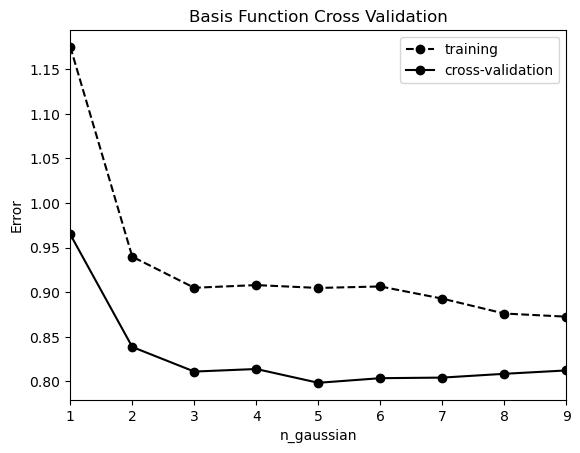

Best n_gaussian: 5 0.79837481555466


In [177]:
n_gaussian = np.arange(1, 10)
train_errors = []
test_errors = []


for n in n_gaussian:
    b_mu = np.linspace(np.min(z_sample),np.max(z_sample),n)[:, None]
    if n == 1: 
        b_sigma = 1
    else:
        b_sigma = 1.0 * (b_mu[1] - b_mu[0])

    model = BasisFunctionRegression('gaussian', mu=b_mu, sigma=b_sigma)
    model.fit(X_train, y_train, dy_train)
    error_train = np.sqrt( np.sum(( y_train - model.predict(X_train) )**2) / len(X_train) )
    error_validation  = np.sqrt( np.sum(( y_validation - model.predict(X_validation) )**2) / len(X_validation) )
    train_errors.append(error_train)
    test_errors.append(error_validation)
    

plt.plot(n_gaussian, train_errors, '--ok', label='training')
plt.plot(n_gaussian, test_errors, '-ok', label='cross-validation')

plt.xlabel('n_gaussian')
plt.ylabel('Error')
plt.title('Basis Function Cross Validation')
#plt.ylim(0.3, 1.5)
plt.xlim(1,9)
plt.legend()
plt.show()

print("Best n_gaussian:", n_gaussian[np.argmin(test_errors)], min(test_errors))
Best_ng = n_gaussian[np.argmin(test_errors)]
best_mu = np.linspace(np.min(z_sample),np.max(z_sample),Best)[:, None]
best_sigma = 1.0 * (best_mu[1] - best_mu[0])

## Kernel regression (Nadaraya-Watson)

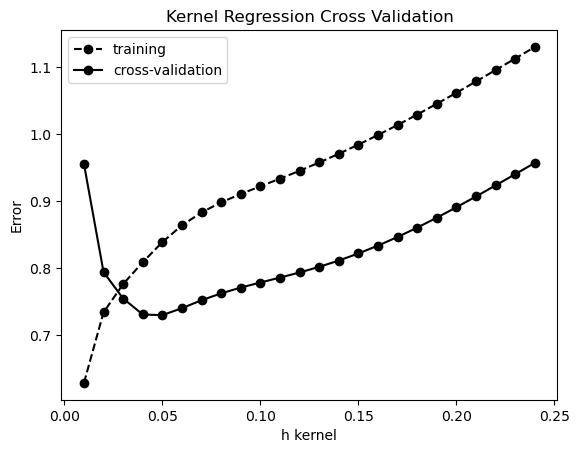

Best h kernel: 0.05 0.7293555893180499


In [178]:
kernel_h = np.arange(0.01, 0.25, 0.01)
train_errors = []
test_errors = []

for h in kernel_h:
    model = NadarayaWatson(kernel='gaussian', h=h)
    model.fit(X_train, y_train, dy_train)
    error_train = np.sqrt( np.sum(( y_train - model.predict(X_train) )**2) / len(X_train) )
    error_validation  = np.sqrt( np.sum(( y_validation - model.predict(X_validation) )**2) / len(X_validation) )
    train_errors.append(error_train)
    test_errors.append(error_validation)
    

plt.plot(kernel_h, train_errors, '--ok', label='training')
plt.plot(kernel_h, test_errors, '-ok', label='cross-validation')

plt.xlabel('h kernel')
plt.ylabel('Error')
plt.title('Kernel Regression Cross Validation')
#plt.ylim(0.3, 1.5)
#plt.xlim(1,9)
plt.legend()
plt.show()

print("Best h kernel:", kernel_h[np.argmin(test_errors)], min(test_errors))
Best_kh = kernel_h[np.argmin(test_errors)]

# Learning Curve for Polynomial Regression

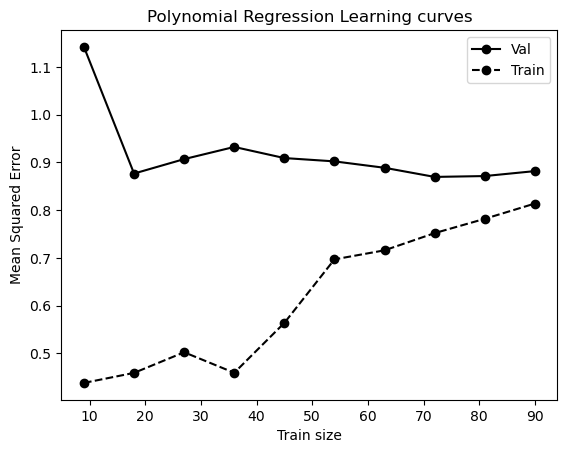

data points: 100


In [179]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

scaler = StandardScaler()
Xscaled = scaler.fit_transform(z_sample[:,np.newaxis])

PolyReg = PolynomialRegression(Best_d)
# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_polyreg, test_scores_polyreg = \
    learning_curve(PolyReg, Xscaled, mu_sample, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_polyreg.mean(1), '-ok', label="Val")
plt.plot(train_sizes, -train_scores_polyreg.mean(1), '--ok', label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Polynomial Regression Learning curves')
plt.legend(loc="best")
plt.show()

print("data points:", len(z_sample))

If the cross validation error is still decreasing and the training error is smaller, it means that the model is dominated by variance and more datapoints can help imporve it.
If the two rms errors are converging, it means that the model is dominated by bias. Thus, if the errors are too high, even more training point will not increase the "goodness" of the model but I rather need a more complex one.

# Best fit model

In [189]:
from astropy.cosmology import LambdaCDM

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
mu_true = cosmo.distmod(zgrid)

C:\Users\balza\anaconda3copia\Lib\site-packages\astropy\cosmology\flrw\base.py:1351: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


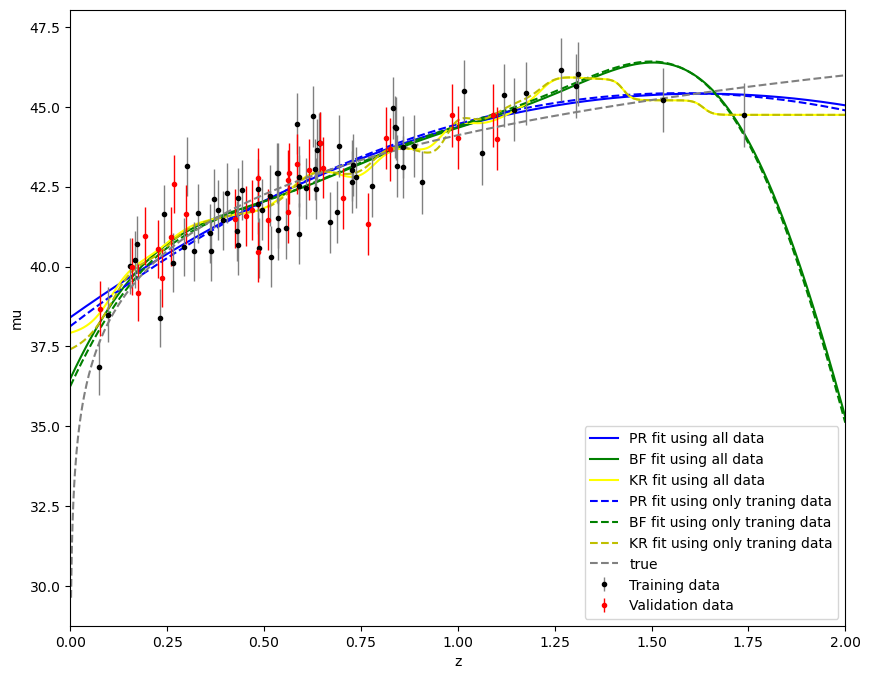

In [191]:
fig = plt.figure(figsize=(10,8))

model_PR = PolynomialRegression(Best_d)
model_BF = BasisFunctionRegression('gaussian', mu=best_mu, sigma=best_sigma)
model_KR = NadarayaWatson(kernel='gaussian', h=Best_kh)


model_PR.fit(z_sample[:,np.newaxis], mu_sample, dmu)
mu_fit_PR = model_PR.predict(zgrid[:,np.newaxis])

model_BF.fit(z_sample[:,np.newaxis], mu_sample, dmu)
mu_fit_BF = model_BF.predict(zgrid[:,np.newaxis])

model_KR.fit(z_sample[:,np.newaxis], mu_sample, dmu)
mu_fit_KR = model_KR.predict(zgrid[:,np.newaxis])


plt.plot(zgrid, mu_fit_PR, 'blue', label='PR fit using all data')
plt.plot(zgrid, mu_fit_BF, 'green', label='BF fit using all data')
plt.plot(zgrid, mu_fit_KR, 'yellow', label='KR fit using all data')


model_PR.fit(X_train, y_train, dy_train)
mu_fit_PR = model_PR.predict(zgrid[:,np.newaxis])

model_BF.fit(X_train, y_train, dy_train)
mu_fit_BF = model_BF.predict(zgrid[:,np.newaxis])

model_KR.fit(X_train, y_train, dy_train)
mu_fit_KR = model_KR.predict(zgrid[:,np.newaxis])


plt.plot(zgrid, mu_fit_PR, '--b', label='PR fit using only traning data')
plt.plot(zgrid, mu_fit_BF, '--g', label='BF fit using only traning data')
plt.plot(zgrid, mu_fit_KR, '--y', label='KR fit using only traning data')


plt.errorbar(X_train, y_train, dy_train, fmt='.k', ecolor='gray', lw=1, label='Training data')
plt.errorbar(X_validation, y_validation, dy_validation, fmt='.r', ecolor='red', lw=1, label='Validation data')

plt.plot(zgrid, mu_true, '--', c='gray', label='true')

plt.xlabel("z")
plt.ylabel("mu")
plt.xlim(0,2)
#plt.ylim(35,50)
plt.legend()
plt.show()

All the model are able to generalize to unseen data, and it is a good sign. Although, Kernel Regression seams to overfit a bit the data, and Basis Function Regression to not actually follow the true fit for high z.